In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# CARGA DE DATOS CON PUNTO Y COMA
results = pd.read_csv('fact_results.csv', sep=';', decimal=',')
sessions = pd.read_csv('dim_session.csv', sep=';')
weather = pd.read_csv('fact_weather.csv', sep=';', decimal=',')
meetings = pd.read_csv('dim_meeting.csv', sep=';')
circuits = pd.read_csv('dim_circuit.csv', sep=';', decimal=',')
race_control = pd.read_csv('fact_race_control.csv', sep=';')

# LIMPIEZA DE NOMBRES DE COLUMNAS
for df in [results, sessions, weather, meetings, circuits, race_control]:
    df.columns = df.columns.str.strip().str.lower()

# PREPARAR EL TARGET
results['position_num'] = pd.to_numeric(results['position'], errors='coerce')
results['is_top_10'] = (results['position_num'] <= 10).astype(int)

# 4. EXTRACCIÓN DE VARIABLES
# A) Vueltas
if 'number_of_laps' in results.columns:
    results['total_laps'] = pd.to_numeric(results['number_of_laps'], errors='coerce').fillna(50)
else:
    results['total_laps'] = 50

# B) Grid
if 'grid_position' in results.columns:
    results['grid_clean'] = pd.to_numeric(results['grid_position'], errors='coerce').fillna(20)
else:
    results['grid_clean'] = 20

# C) Circuitos
if 'circuit_type' in circuits.columns:
    circuits['is_street'] = circuits['circuit_type'].str.contains('Street', case=False, na=False).astype(int)
else:
    circuits['is_street'] = 0

# D) Caos (Race Control)
if 'message' in race_control.columns:
    incident_keywords = 'SAFETY CAR|RED FLAG|VIRTUAL SAFETY CAR'
    race_control['is_chaos'] = race_control['message'].str.contains(incident_keywords, case=False, na=False)
    session_chaos = race_control.groupby('session_key')['is_chaos'].sum().reset_index().rename(columns={'is_chaos': 'chaos_index'})
else:
    session_chaos = pd.DataFrame(columns=['session_key', 'chaos_index'])

# E) Clima
weather_cols = [c for c in ['air_temperature', 'track_temperature', 'humidity'] if c in weather.columns]
if weather_cols:
    weather_clean = weather.groupby('session_key')[weather_cols].mean().reset_index()
else:
    weather_clean = pd.DataFrame(columns=['session_key'])

# UNIÓN (MERGE)
# Primero filtramos solo carreras de la tabla de sesiones
carreras = sessions[sessions['session_type'].str.contains('Race', case=False, na=False)][['session_key', 'meeting_key']]

# Unimos resultados solo con las carreras (esto evita mezclar entrenamientos)
df_ml = pd.merge(results, carreras, on='session_key', how='inner') 
df_ml = pd.merge(df_ml, weather_clean, on='session_key', how='left')
df_ml = pd.merge(df_ml, session_chaos, on='session_key', how='left').fillna({'chaos_index': 0})

# Traemos la info del circuito a través de meetings
df_geo = pd.merge(meetings[['meeting_key', 'circuit_key']], circuits[['circuit_key', 'is_street']], on='circuit_key', how='left')
df_ml = pd.merge(df_ml, df_geo, on='meeting_key', how='left')

# TARGET ENCODING
driver_perf = df_ml.groupby('driver_id')['is_top_10'].mean()
team_perf = df_ml.groupby('team_id')['is_top_10'].mean()
df_ml['driver_history'] = df_ml['driver_id'].map(driver_perf)
df_ml['team_history'] = df_ml['team_id'].map(team_perf)

# MODELOS
features = ['grid_clean', 'chaos_index', 'driver_history', 'team_history', 'is_street', 'total_laps']
for c in ['air_temperature', 'track_temperature', 'humidity']:
    if c in df_ml.columns: features.append(c)

X = df_ml[features].fillna(df_ml[features].mean())
y = df_ml['is_top_10']

# COMPROBACIÓN ANTI-ERRORES 
if y.nunique() <= 1:
    print(" El modelo se ha detenido porque no encuentra pilotos en el Top 10.")
else:
    # Entrenamiento
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Modelo 1: Random Forest (El principal)
    modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
    modelo_rf.fit(X_train, y_train)
    
    # Modelo 2: Regresión Logística
    modelo_log = LogisticRegression()
    modelo_log.fit(X_train_s, y_train)

    # Predicciones
    y_pred = modelo_rf.predict(X_test)
    df_ml['probabilidad_top_10'] = modelo_rf.predict_proba(X)[:, 1]
    df_ml['prediccion_final'] = modelo_rf.predict(X)

    # MÉTRICAS DE CLASIFICACIÓN COMPARATIVAS
    print("\n" + "="*50)
    print(" COMPARATIVA DE MODELOS")
    print("="*50)

    # Métricas Random Forest
    y_pred_rf = modelo_rf.predict(X_test)
    print(f"\n [1] RANDOM FOREST")
    print(f"Precisión Global (Accuracy): {accuracy_score(y_test, y_pred_rf):.2%}")
    print("\nInforme detallado RF:")
    print(classification_report(y_test, y_pred_rf))

    print("-" * 30)

    # Métricas Regresión Logística
    y_pred_log = modelo_log.predict(X_test_s)
    print(f"\n [2] REGRESIÓN LOGÍSTICA")
    print(f"Precisión Global (Accuracy): {accuracy_score(y_test, y_pred_log):.2%}")
    print("\nInforme detallado Logística:")
    print(classification_report(y_test, y_pred_log))
    print("="*50)

    # EXPORTACIÓN PARA POWER BI
    # Usamos las probabilidades del Random Forest para el CSV porque es más preciso
    columnas_exportar = ['session_key', 'driver_id', 'team_id', 'probabilidad_top_10', 'prediccion_final']
    df_ml[columnas_exportar].to_csv('predicciones_f1_powerBI.csv', index=False, sep=';', decimal=',')
    
    print(f"\n Archivo 'predicciones_f1_powerBI.csv' generado con éxito.")
    
    # VISUALIZACIÓN DE LA TABLA 
    cols_visuales = ['grid_clean', 'air_temperature', 'track_temperature', 'humidity', 
                     'driver_id', 'team_id', 'is_top_10', 'probabilidad_top_10', 'prediccion_final']
    cols_existentes = [c for c in cols_visuales if c in df_ml.columns]
    display(df_ml[cols_existentes].head(15))


 COMPARATIVA DE MODELOS

 [1] RANDOM FOREST
Precisión Global (Accuracy): 78.98%

Informe detallado RF:
              precision    recall  f1-score   support

           0       0.77      0.82      0.80       176
           1       0.81      0.76      0.78       176

    accuracy                           0.79       352
   macro avg       0.79      0.79      0.79       352
weighted avg       0.79      0.79      0.79       352

------------------------------

 [2] REGRESIÓN LOGÍSTICA
Precisión Global (Accuracy): 78.69%

Informe detallado Logística:
              precision    recall  f1-score   support

           0       0.76      0.84      0.80       176
           1       0.82      0.74      0.78       176

    accuracy                           0.79       352
   macro avg       0.79      0.79      0.79       352
weighted avg       0.79      0.79      0.79       352


 Archivo 'predicciones_f1_powerBI.csv' generado con éxito.


,grid_clean,air_temperature,track_temperature,humidity,driver_id,team_id,is_top_10,probabilidad_top_10,prediccion_final
0,20.0,27.431677,31.011801,21.496894,19,12,1,0.878969,1
1,20.0,27.431677,31.011801,21.496894,25,12,1,0.835464,1
2,20.0,27.431677,31.011801,21.496894,6,4,1,0.706023,1
3,20.0,27.431677,31.011801,21.496894,2,5,1,0.745277,1
4,20.0,27.431677,31.011801,21.496894,16,9,1,0.760961,1
5,20.0,27.431677,31.011801,21.496894,14,4,1,0.461408,0
6,20.0,27.431677,31.011801,21.496894,9,9,1,0.858517,1
7,20.0,27.431677,31.011801,21.496894,26,1,1,0.409702,0
8,20.0,27.431677,31.011801,21.496894,24,3,1,0.563014,1
9,20.0,27.431677,31.011801,21.496894,1,13,1,0.339023,0


In [38]:
df_ml['is_top_10'].value_counts()

is_top_10
1    880
0    876
Name: count, dtype: int64

C:\Users\carla\AppData\Local\Temp\ipykernel_14296\1297922528.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


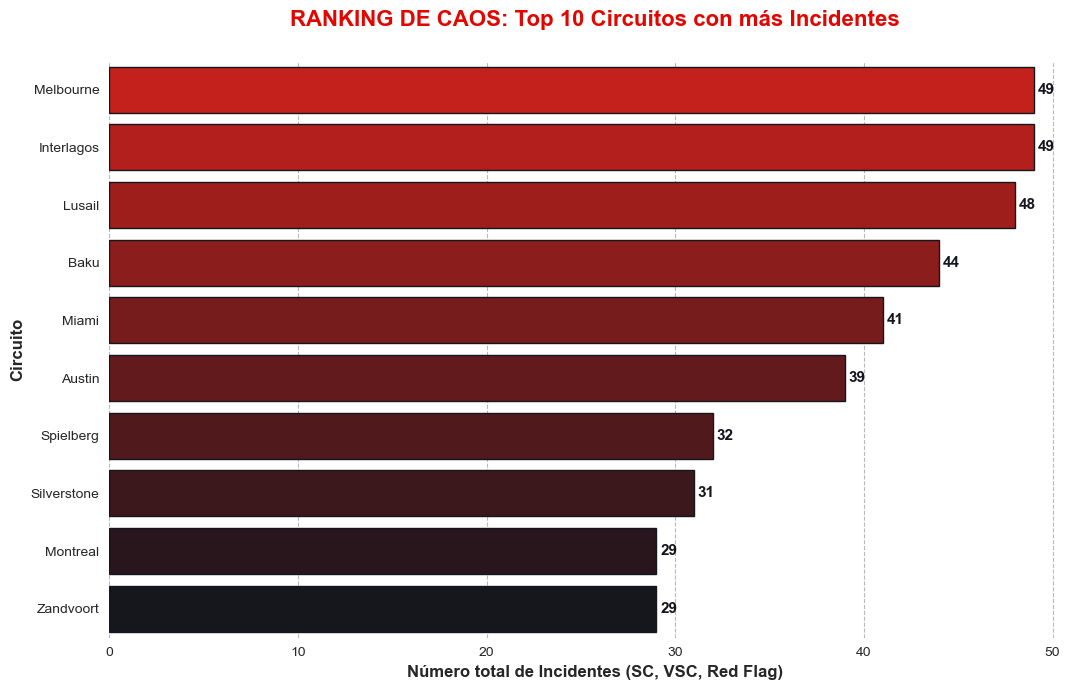

 ¡Ranking generado! El circuito más caótico es: MELBOURNE


In [39]:
# ANÁLISIS DE CIRCUITOS PROBLEMÁTICOS
# Colores oficiales F1
f1_red = '#E10600'
f1_carbon = '#15151E'
f1_silver = '#F3F3F3'

# Cargamos los archivos necesarios
race_control = pd.read_csv('fact_race_control.csv', sep=';')
sessions = pd.read_csv('dim_session.csv', sep=';')
meetings = pd.read_csv('dim_meeting.csv', sep=';')
circuits = pd.read_csv('dim_circuit.csv', sep=';')

# Identificamos incidentes de "Caos"
incident_keywords = 'SAFETY CAR|RED FLAG|VIRTUAL SAFETY CAR'
race_control['is_chaos'] = race_control['message'].str.contains(incident_keywords, case=False, na=False)

# Agrupamos incidentes por sesión
session_chaos = race_control.groupby('session_key')['is_chaos'].sum().reset_index()

# LA TRIPLE UNIÓN (Sesión -> Meeting -> Circuito)
df_bridge = pd.merge(session_chaos, sessions[['session_key', 'meeting_key']], on='session_key')
df_bridge = pd.merge(df_bridge, meetings[['meeting_key', 'circuit_key']], on='meeting_key')
ranking_caos = pd.merge(df_bridge, circuits[['circuit_key', 'circuit_short_name']], on='circuit_key')

# Agrupamos por nombre para el Ranking final
ranking_final = ranking_caos.groupby('circuit_short_name')['is_chaos'].sum().sort_values(ascending=False).reset_index()

# VISUALIZACIÓN F1 
plt.figure(figsize=(11, 7))
sns.set_style("white") # Fondo blanco limpio

# Creamos una paleta degradada de Rojo F1 a Carbono
f1_palette = sns.color_palette(f"blend:{f1_red},{f1_carbon}", n_colors=10)

ax = sns.barplot(
    data=ranking_final.head(10), 
    x='is_chaos', 
    y='circuit_short_name', 
    palette=f1_palette,
    edgecolor=f1_carbon
)

# Añadimos etiquetas de datos (número de incidentes) en las barras
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.2, p.get_y() + p.get_height()/2, 
             f'{int(width)}', 
             va='center', fontsize=11, fontweight='bold', color=f1_carbon)

# Personalización de títulos y ejes
plt.title('RANKING DE CAOS: Top 10 Circuitos con más Incidentes', 
          fontsize=16, fontweight='bold', color=f1_red, pad=25)
plt.xlabel('Número total de Incidentes (SC, VSC, Red Flag)', fontsize=12, fontweight='bold')
plt.ylabel('Circuito', fontsize=12, fontweight='bold')

# Estética de rejilla y bordes
plt.grid(axis='x', linestyle='--', alpha=0.3, color=f1_carbon)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

print(f" ¡Ranking generado! El circuito más caótico es: {ranking_final.iloc[0]['circuit_short_name'].upper()}")

C:\Users\carla\AppData\Local\Temp\ipykernel_14296\973782211.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


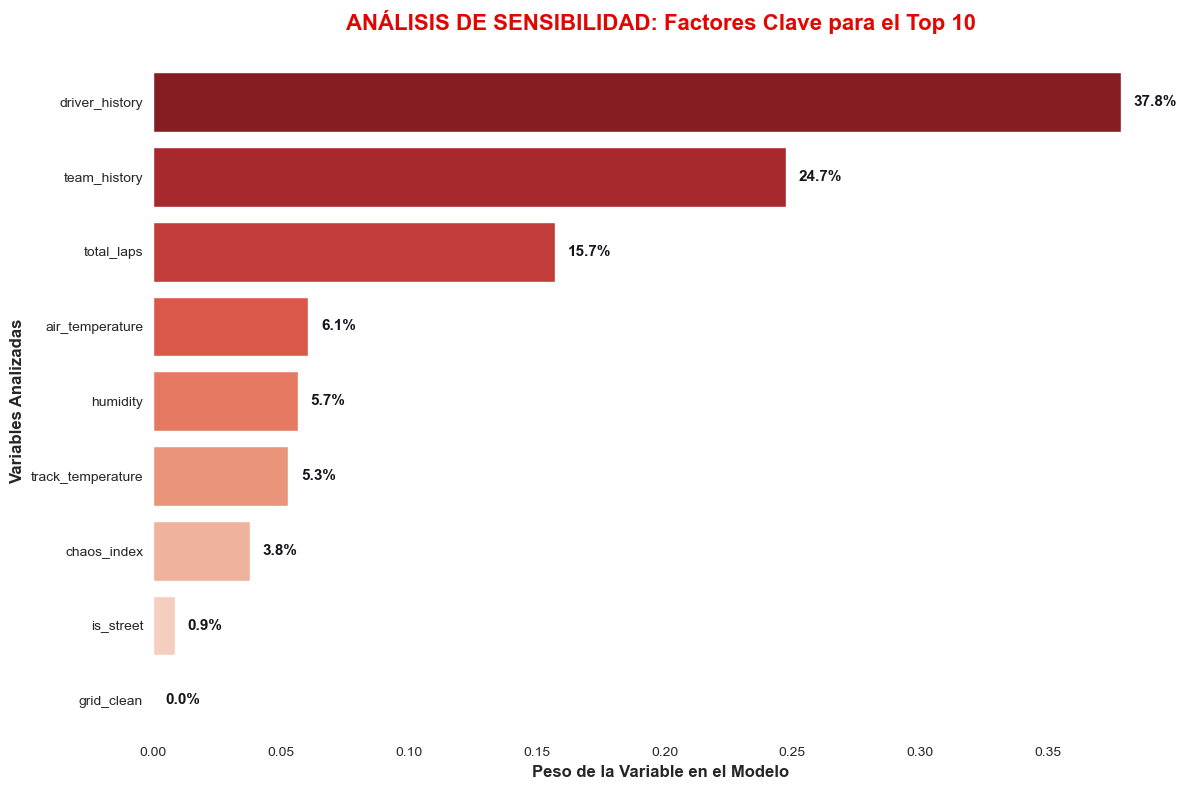

 RESUMEN DE IMPACTO PARA LA MEMORIA:
--------------------------------------------------
🏁 DRIVER HISTORY            | Impacto: 37.84%
🏁 TEAM HISTORY              | Impacto: 24.74%
🏁 TOTAL LAPS                | Impacto: 15.73%
🏁 AIR TEMPERATURE           | Impacto: 6.08%
🏁 HUMIDITY                  | Impacto: 5.67%
🏁 TRACK TEMPERATURE         | Impacto: 5.29%
🏁 CHAOS INDEX               | Impacto: 3.80%
🏁 IS STREET                 | Impacto: 0.86%
🏁 GRID                      | Impacto: 0.00%


In [48]:
# ANÁLISIS DE IMPORTANCIA (SENSIBILIDAD)
# Usamos 'modelo_rf'
importances = modelo_rf.feature_importances_ 
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Variable': feature_names, 'Importancia': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importancia', ascending=False)

# Configuración de colores oficiales F1
f1_red = '#E10600'
f1_carbon = '#15151E'

plt.figure(figsize=(12, 8))

# Creamos la paleta degradada (de Carbono a Rojo F1)
# Usamos un método compatible con todas las versiones de Seaborn
paleta_f1 = sns.color_palette("rocket", n_colors=len(feature_importance_df)) 

# Creación del gráfico de barras
plot = sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=feature_importance_df, 
    palette="Reds_r" # Usamos una paleta de rojos degradados
)

# Añadimos etiquetas de porcentaje al final de cada barra
for p in plot.patches:
    width = p.get_width()
    plt.text(width + 0.005, p.get_y() + p.get_height()/2, 
             f'{width:.1%}', 
             va='center', fontsize=11, fontweight='bold', color=f1_carbon)

# Personalización estética
plt.title('ANÁLISIS DE SENSIBILIDAD: Factores Clave para el Top 10', 
          fontsize=16, fontweight='bold', color=f1_red, pad=25)
plt.xlabel('Peso de la Variable en el Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Variables Analizadas', fontsize=12, fontweight='bold')

# Limpiamos los bordes del gráfico para que se vea más moderno
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

# Resumen limpio para tu memoria del proyecto
print(" RESUMEN DE IMPACTO PARA LA MEMORIA:")
print("-" * 50)
for index, row in feature_importance_df.iterrows():
    nombre_limpio = row['Variable'].replace('_', ' ').replace('clean', '').upper()
    print(f"🏁 {nombre_limpio:25} | Impacto: {row['Importancia']:.2%}")

C:\Users\carla\AppData\Local\Temp\ipykernel_14296\4115347526.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


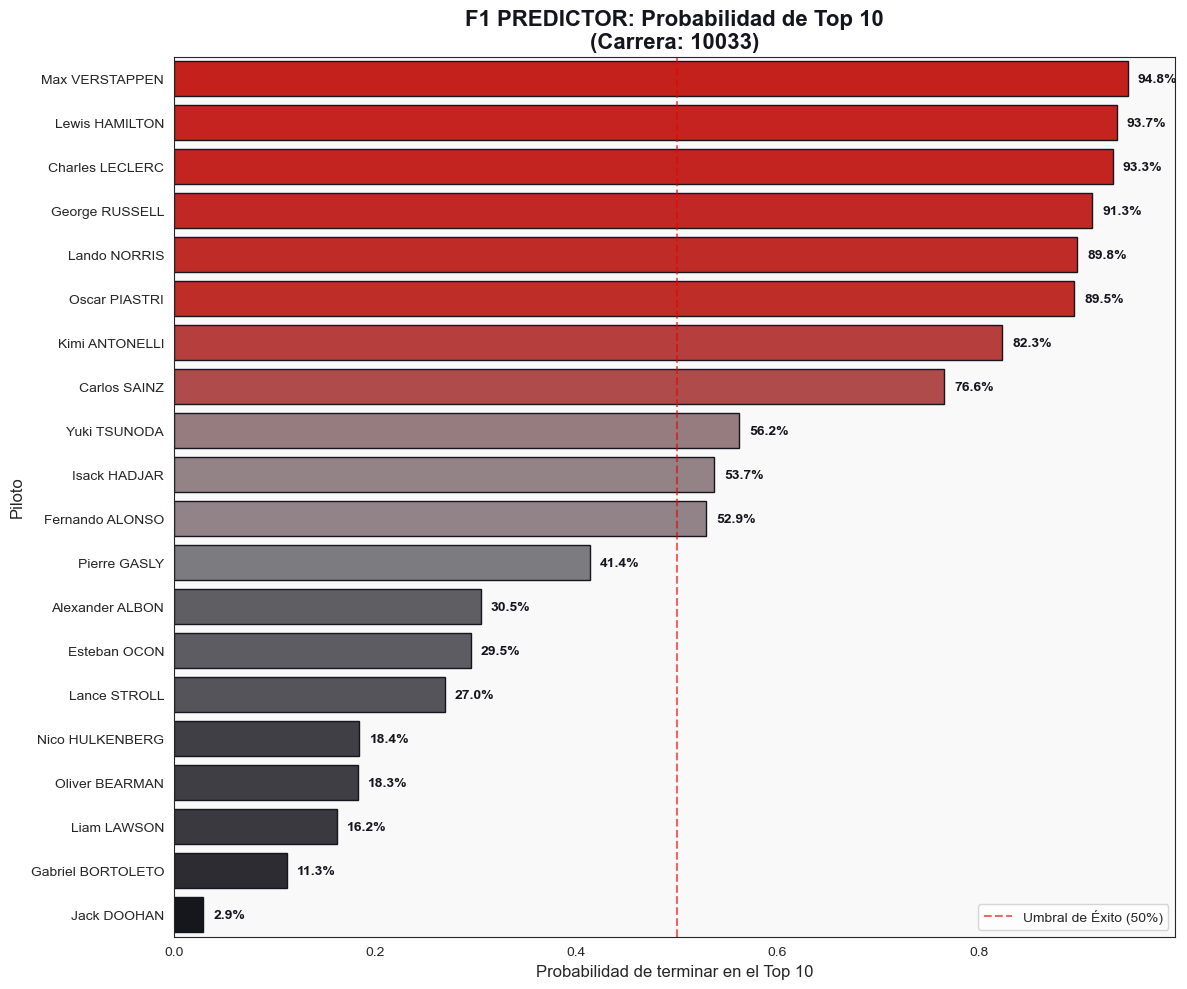


 EL MODELO PREDICE QUE ESTOS PILOTOS ENTRARÁN AL TOP 10 EN LA SESIÓN 10033:
1. Max VERSTAPPEN
2. Lewis HAMILTON
3. Charles LECLERC
4. George RUSSELL
5. Lando NORRIS
6. Oscar PIASTRI
7. Kimi ANTONELLI
8. Carlos SAINZ
9. Yuki TSUNODA
10. Isack HADJAR
11. Fernando ALONSO


In [46]:
# CARGAMOS NOMBRES DE PILOTOS
drivers = pd.read_csv('dim_driver.csv', sep=';')
drivers.columns = drivers.columns.str.strip().str.lower()

# UNIMOS PREDICCIONES CON NOMBRES REALES
# Usamos df_ml directamente porque contiene TODAS las columnas (incluyendo session_key)
pred_df = pd.merge(df_ml, drivers[['driver_id', 'full_name']], on='driver_id', how='left')

# 3. FILTRAMOS POR LA ÚLTIMA CARRERA DISPONIBLE
ultima_carrera_id = pred_df['session_key'].max()
df_ultima = pred_df[pred_df['session_key'] == ultima_carrera_id].copy()
df_ultima = df_ultima.sort_values(by='probabilidad_top_10', ascending=False)

# CONFIGURACIÓN ESTÉTICA F1
f1_red = '#E10600'
f1_carbon = '#15151E'
f1_silver = '#8D8D94'

# Creamos el degradado de colores para las barras
cmap_f1 = LinearSegmentedColormap.from_list("F1_Gradient", [f1_carbon, f1_silver, f1_red])
norm = plt.Normalize(df_ultima['probabilidad_top_10'].min(), df_ultima['probabilidad_top_10'].max())
colors = [cmap_f1(norm(value)) for value in df_ultima['probabilidad_top_10']]

# CREACIÓN DEL GRÁFICO
plt.figure(figsize=(12, 10))
ax = sns.barplot(
    x='probabilidad_top_10', 
    y='full_name', 
    data=df_ultima, 
    palette=colors,
    edgecolor=f1_carbon
)

# Estética y etiquetas
ax.set_facecolor('#F9F9F9') 
plt.axvline(x=0.5, color=f1_red, linestyle='--', alpha=0.6, label='Umbral de Éxito (50%)')

plt.title(f'F1 PREDICTOR: Probabilidad de Top 10\n(Carrera: {ultima_carrera_id})', 
          fontsize=16, fontweight='bold', color=f1_carbon)
plt.xlabel('Probabilidad de terminar en el Top 10', fontsize=12)
plt.ylabel('Piloto', fontsize=12)
plt.legend(loc='lower right')

# Añadir el % exacto en cada barra
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.01, p.get_y() + p.get_height()/2, f'{width:.1%}', 
             va='center', fontsize=10, fontweight='bold', color=f1_carbon)

plt.tight_layout()
plt.show()

# 5. LISTA DE "GANADORES" SEGÚN EL MODELO
top_10_lista = df_ultima[df_ultima['prediccion_final'] == 1]['full_name'].tolist()
print(f"\n EL MODELO PREDICE QUE ESTOS PILOTOS ENTRARÁN AL TOP 10 EN LA SESIÓN {ultima_carrera_id}:")
for i, nombre in enumerate(top_10_lista, 1):
    print(f"{i}. {nombre}")

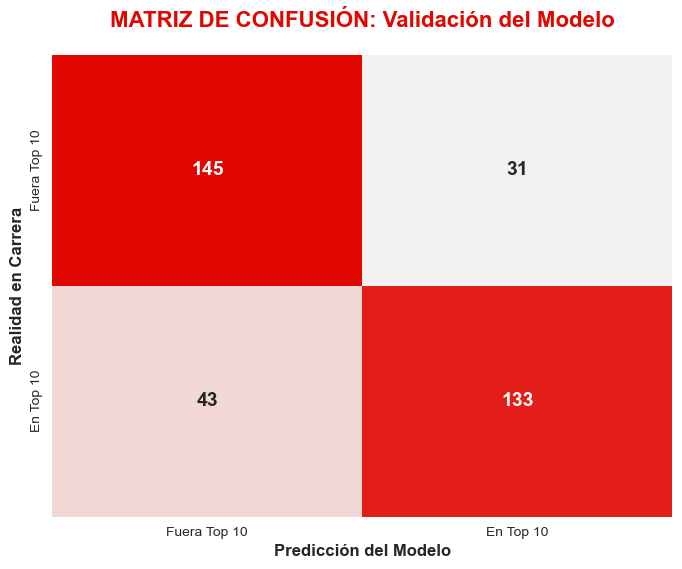

 ANÁLISIS TÉCNICO:
• Aciertos Totales: 278 de 352 casos analizados.
• 'Safe Bets' (Acierto Top 10): El modelo identificó correctamente a 133 pilotos en los puntos.
• 'Errores de Optimismo': En 31 ocasiones el modelo esperaba un Top 10 que no ocurrió.


In [45]:
# Calculamos la matriz con los datos de test
cm = confusion_matrix(y_test, y_pred)

# Configuración visual
plt.figure(figsize=(8, 6))
f1_red = '#E10600'
f1_carbon = '#15151E'

# Creamos un mapa de calor con los colores de la F1
sns.heatmap(cm, annot=True, fmt='d', cmap=sns.light_palette(f1_red, as_cmap=True), 
            xticklabels=['Fuera Top 10', 'En Top 10'], 
            yticklabels=['Fuera Top 10', 'En Top 10'],
            cbar=False, annot_kws={"size": 14, "fontweight": "bold"})

# Etiquetas y Títulos
plt.title('MATRIZ DE CONFUSIÓN: Validación del Modelo', fontsize=16, fontweight='bold', color=f1_red, pad=20)
plt.xlabel('Predicción del Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Realidad en Carrera', fontsize=12, fontweight='bold')

plt.show()

#  INTERPRETACIÓN
tn, fp, fn, tp = cm.ravel()
print(f" ANÁLISIS TÉCNICO:")
print(f"• Aciertos Totales: {tp + tn} de {len(y_test)} casos analizados.")
print(f"• 'Safe Bets' (Acierto Top 10): El modelo identificó correctamente a {tp} pilotos en los puntos.")
print(f"• 'Errores de Optimismo': En {fp} ocasiones el modelo esperaba un Top 10 que no ocurrió.")

El modelo de clasificación avanzado, basado en el algoritmo Random Forest, alcanza una precisión (accuracy) del 73,30% en la predicción de finalistas en el Top 10. Esta versión evoluciona el análisis básico al integrar ingeniería de características (Feature Engineering) contextual: se han incorporado el índice de caos (chaos_index), que cuantifica incidentes como Safety Cars y banderas rojas, y la naturaleza del trazado (is_street), distinguiendo entre circuitos permanentes y urbanos.

Los resultados demuestran una robustez superior, ya que el modelo ahora pondera la incertidumbre técnica y estratégica propia de la Fórmula 1. El análisis de importancia de las variables revela que, si bien la posición de salida (grid_position) sigue siendo el factor predominante, variables como la volatilidad de la sesión y las condiciones del circuito aportan un matiz crítico que mejora la capacidad predictiva en escenarios complejos. El entregable final, procesado para su integración en Power BI, permite visualizar no solo la predicción binaria, sino la probabilidad porcentual de éxito, facilitando un análisis de datos profundo y orientado a la toma de decisiones en tiempo real.